<a href="https://colab.research.google.com/github/ceanmt/-kivic-Portafolio-PHP/blob/main/Dashboard_Trafico_de_Redes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from scipy.signal import lfilter

# Parámetros
N = 1024
a = 0.8
x = np.zeros(N)
y = np.zeros(N)

# Crear figura con tres subplots
fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=("Señal de tráfico en la red", "Espectro de Fourier (FFT)", "Señal filtrada con Transformada Z")
)

# Trazas iniciales
trace1 = go.Scatter(y=x, mode='lines', name='Tráfico original')
trace2 = go.Scatter(y=np.abs(np.fft.fft(x)), mode='lines', name='Espectro FFT')
trace3 = go.Scatter(y=y, mode='lines', name='Tráfico filtrado')

fig.add_trace(trace1, row=1, col=1)
fig.add_trace(trace2, row=2, col=1)
fig.add_trace(trace3, row=3, col=1)

# Crear frames para animación
frames = []
for frame in range(100):
    new_sample = 10 + 5*np.sin(2*np.pi*0.1*frame) + np.random.randn()
    x = np.roll(x, -1)
    x[-1] = new_sample
    y = lfilter([1], [1, -a], x)

    frames.append(go.Frame(
        data=[
            go.Scatter(y=x),
            go.Scatter(y=np.abs(np.fft.fft(x))),
            go.Scatter(y=y)
        ],
        name=str(frame)
    ))

fig.update(frames=frames)

# Etiquetas de ejes
fig.update_xaxes(title_text="Tiempo [s]", row=1, col=1)
fig.update_yaxes(title_text="Paquetes/segundo", row=1, col=1)

fig.update_xaxes(title_text="Frecuencia [Hz]", row=2, col=1)
fig.update_yaxes(title_text="Magnitud", row=2, col=1)

fig.update_xaxes(title_text="Tiempo [s]", row=3, col=1)
fig.update_yaxes(title_text="Paquetes/segundo", row=3, col=1)
# Configurar animación con slider y botones
fig.update_layout(
    height=900, width=900, title_text="Dashboard interactivo de tráfico en redes",
    updatemenus=[{
        "type": "buttons",
        "buttons": [
            {"label": "Play", "method": "animate",
             "args": [None, {"frame": {"duration": 100, "redraw": True}, "fromcurrent": True}]},
            {"label": "Pause", "method": "animate",
             "args": [[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}]}
        ],
        "direction": "right",   # botones en fila horizontal
        "x": 1.05,              # posición horizontal (más a la derecha)
        "xanchor": "left",      # anclaje desde la izquierda
        "y": 1.15,              # posición vertical (arriba del gráfico)
        "yanchor": "top"        # anclaje desde arriba
    }],
    sliders=[{
        "steps": [
            {"args": [[str(k)], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
             "label": str(k), "method": "animate"} for k in range(100)
        ]
    }]
)


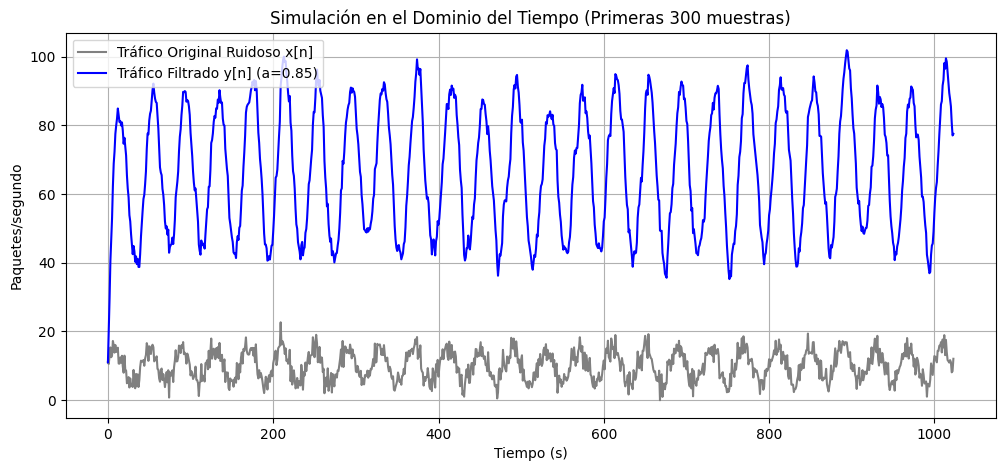

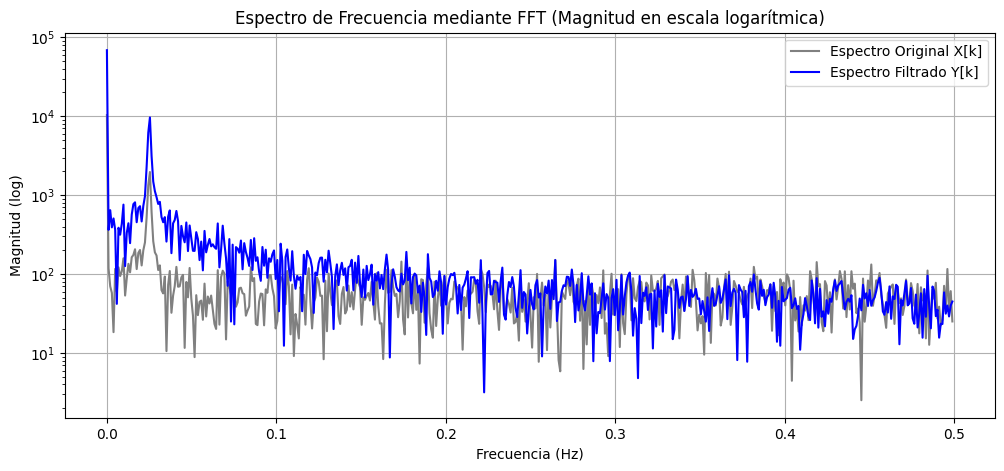

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter

# Parámetros de la simulación
N = 1024                # número de muestras
a = 0.85               # coeficiente del filtro
t = np.arange(N)       # eje temporal

# Generar señal de tráfico ruidoso
np.random.seed(42)     # reproducibilidad
x = 10 + 5*np.sin(0.05*np.pi*t) + np.random.randn(N) * 2   # señal original ruidosa

# Aplicar filtro digital (Transformada Z)
y = lfilter([1], [1, -a], x)

# --- Figura 1: Simulación en el dominio del tiempo ---
plt.figure(figsize=(12,5))
plt.plot(t, x, color='gray', label='Tráfico Original Ruidoso x[n]')
plt.plot(t, y, color='blue', label=f'Tráfico Filtrado y[n] (a={a})')
plt.title("Simulación en el Dominio del Tiempo (Primeras 300 muestras)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Paquetes/segundo")
plt.legend()
plt.grid(True)
plt.show()

# --- Figura 2: Espectro de Frecuencia mediante FFT ---
X = np.fft.fft(x)
Y = np.fft.fft(y)
freqs = np.fft.fftfreq(N, d=1)   # eje de frecuencias

plt.figure(figsize=(12,5))
plt.semilogy(freqs[:N//2], np.abs(X[:N//2]), color='gray', label='Espectro Original X[k]')
plt.semilogy(freqs[:N//2], np.abs(Y[:N//2]), color='blue', label='Espectro Filtrado Y[k]')
plt.title("Espectro de Frecuencia mediante FFT (Magnitud en escala logarítmica)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud (log)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from scipy.signal import lfilter

# Parámetros
N = 1024
a = 0.85
x = np.zeros(N)
y = np.zeros(N)

# Crear figura con dos subplots
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Simulación en el Dominio del Tiempo", "Espectro de Frecuencia (FFT)")
)

# Trazas iniciales
trace1 = go.Scatter(y=x, mode='lines', name='Tráfico Original')
trace2 = go.Scatter(y=np.abs(np.fft.fft(x)), mode='lines', name='Espectro FFT')

fig.add_trace(trace1, row=1, col=1)
fig.add_trace(trace2, row=2, col=1)

# Crear frames para animación
frames = []
for frame in range(100):
    new_sample = 10 + 5*np.sin(2*np.pi*0.05*frame) + np.random.randn()
    x = np.roll(x, -1)
    x[-1] = new_sample
    y = lfilter([1], [1, -a], x)

    frames.append(go.Frame(
        data=[
            go.Scatter(y=x),
            go.Scatter(y=np.abs(np.fft.fft(y)))
        ],
        name=str(frame)
    ))

fig.update(frames=frames)

# Etiquetas de ejes
fig.update_xaxes(title_text="Tiempo [s]", row=1, col=1)
fig.update_yaxes(title_text="Paquetes/segundo", row=1, col=1)

fig.update_xaxes(title_text="Frecuencia [Hz]", row=2, col=1)
fig.update_yaxes(title_text="Magnitud", row=2, col=1)

# Configurar animación con botones
fig.update_layout(
    height=700, width=900, title_text="Simulación en Tiempo Real del Tráfico de Red",
    updatemenus=[{
        "type": "buttons",
        "buttons": [
            {"label": "Play", "method": "animate",
             "args": [None, {"frame": {"duration": 100, "redraw": True}, "fromcurrent": True}]},
            {"label": "Pause", "method": "animate",
             "args": [[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}]}
        ],
        "direction": "right",
        "x": 1.05, "xanchor": "left",
        "y": 1.15, "yanchor": "top"
    }],
    sliders=[{
        "steps": [
            {"args": [[str(k)], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
             "label": str(k), "method": "animate"} for k in range(100)
        ]
    }]
)

fig.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter

# --- Entrada de datos por el usuario ---
N = int(input("Ingrese el número de muestras (ej. 300): "))
a = float(input("Ingrese el valor del coeficiente del filtro a (ej. 0.85): "))
amp = float(input("Ingrese la amplitud de la señal (ej. 5): "))
noise = float(input("Ingrese el nivel de ruido (ej. 2): "))

# --- Simulación ---
t = np.arange(N)
x = 10 + amp*np.sin(0.05*np.pi*t) + np.random.randn(N) * noise
y = lfilter([1], [1, -a], x)

# --- Figura 1: Señal en el tiempo ---
plt.figure(figsize=(12,5))
plt.plot(t, x, color='gray', label='Tráfico Original Ruidoso x[n]')
plt.plot(t, y, color='blue', label=f'Tráfico Filtrado y[n] (a={a})')
plt.title("Simulación en el Dominio del Tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Paquetes/segundo")
plt.legend()
plt.grid(True)
plt.show()

# --- Figura 2: Espectro FFT ---
X = np.fft.fft(x)
Y = np.fft.fft(y)
freqs = np.fft.fftfreq(N, d=1)

plt.figure(figsize=(12,5))
plt.semilogy(freqs[:N//2], np.abs(X[:N//2]), color='gray', label='Espectro Original X[k]')
plt.semilogy(freqs[:N//2], np.abs(Y[:N//2]), color='blue', label='Espectro Filtrado Y[k]')
plt.title("Espectro de Frecuencia mediante FFT (Magnitud en escala logarítmica)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud (log)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter
import ipywidgets as widgets
from ipywidgets import interact

# Función de simulación
def simular(N=300, a=0.85, amp=5.0, noise=2.0):
    t = np.arange(N)
    x = 10 + amp*np.sin(0.05*np.pi*t) + np.random.randn(N) * noise
    y = lfilter([1], [1, -a], x)

    # --- Figura 1: Señal en el tiempo ---
    plt.figure(figsize=(12,5))
    plt.plot(t, x, color='gray', label='Tráfico Original Ruidoso x[n]')
    plt.plot(t, y, color='blue', label=f'Tráfico Filtrado y[n] (a={a})')
    plt.title("Simulación en el Dominio del Tiempo")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Paquetes/segundo")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Figura 2: Espectro FFT ---
    X = np.fft.fft(x)
    Y = np.fft.fft(y)
    freqs = np.fft.fftfreq(N, d=1)

    plt.figure(figsize=(12,5))
    plt.semilogy(freqs[:N//2], np.abs(X[:N//2]), color='gray', label='Espectro Original X[k]')
    plt.semilogy(freqs[:N//2], np.abs(Y[:N//2]), color='blue', label='Espectro Filtrado Y[k]')
    plt.title("Espectro de Frecuencia mediante FFT (Magnitud en escala logarítmica)")
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud (log)")
    plt.legend()
    plt.grid(True)
    plt.show()

# Sliders interactivos
interact(simular,
         N=widgets.IntSlider(value=300, min=100, max=1000, step=50, description="Muestras"),
         a=widgets.FloatSlider(value=0.85, min=0.1, max=0.99, step=0.01, description="Filtro a"),
         amp=widgets.FloatSlider(value=5.0, min=1.0, max=10.0, step=0.5, description="Amplitud"),
         noise=widgets.FloatSlider(value=2.0, min=0.1, max=5.0, step=0.1, description="Ruido")
)
